# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(replace with your name)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: banistlx@dukes.jmu.edu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:04<00:00, 84.7MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

=== Dataset Distribution Summary ===
Fire images: 755 (75.58%)
Non-fire images: 244 (24.42%)
Total images: 999


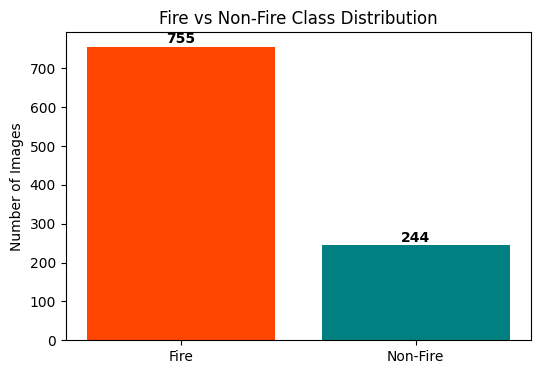

In [4]:
# Your exploration here

# Count files in each class directory
fire_dir = "fire-dataset/fire_dataset/fire_images"
non_fire_dir = "fire-dataset/fire_dataset/non_fire_images"

num_fire = len(os.listdir(fire_dir))
num_non_fire = len(os.listdir(non_fire_dir))
total_images = num_fire + num_non_fire

print("=== Dataset Distribution Summary ===")
print(f"Fire images: {num_fire} ({num_fire/total_images*100:.2f}%)")
print(f"Non-fire images: {num_non_fire} ({num_non_fire/total_images*100:.2f}%)")
print(f"Total images: {total_images}")

# Visualize the distribution
fig, ax = plt.subplots(figsize=(6, 4))
classes = ['Fire', 'Non-Fire']
counts = [num_fire, num_non_fire]
ax.bar(classes, counts, color=['orangered', 'teal'])
ax.set_ylabel('Number of Images')
ax.set_title('Fire vs Non-Fire Class Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

About 75% of the images this dataset contains are images of fire and about 25% are images of non fire. Since the picture percentages are uneven, the data should be stratified when splitting.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [5]:
# Preprocess the data here
def preprocess_for_mobilenet(images, labels):
    # MobileNetV2 preprocess_input expects float values in range [-1, 1]
    return preprocess_input(images), labels

train_fire = train_raw_fire.map(preprocess_for_mobilenet)
val_fire = val_raw_fire.map(preprocess_for_mobilenet)
test_fire = test_raw_fire.map(preprocess_for_mobilenet)

In [6]:
# Build your model here

# Load pre-trained MobileNetV2 base model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model weights
base_model.trainable = False

# Construct the model pipeline
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # keep base model in inference mode
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation='sigmoid')(x)  # Single unit for binary classification (fire/non-fire)

model = Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Compile the model using Binary Crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 1D — Train and Evaluate

In [10]:
# Train your model here
history = model.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10,
    verbose=1
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8771 - loss: 0.3018 - val_accuracy: 0.9281 - val_loss: 0.2281
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9657 - loss: 0.1246 - val_accuracy: 0.9568 - val_loss: 0.1385
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9800 - loss: 0.0892 - val_accuracy: 0.9496 - val_loss: 0.1175
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9857 - loss: 0.0713 - val_accuracy: 0.9568 - val_loss: 0.0860
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9914 - loss: 0.0618 - val_accuracy: 0.9856 - val_loss: 0.0665
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9900 - loss: 0.0546 - val_accuracy: 0.9568 - val_loss: 0.1044
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9929 - loss: 0.0500 - val_accuracy: 0.9496 - val_loss: 0.0981
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9929 - loss: 0.0446 - val_accuracy: 0.9640 - val_loss:

In [13]:
# Report validation and test accuracy here

val_loss, val_acc = model.evaluate(val_fire, verbose=0)
test_loss, test_acc = model.evaluate(test_fire, verbose=0)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

Validation Loss: 0.0831
Validation Accuracy: 97.84%
Test Loss: 0.0807
Test Accuracy: 97.50%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

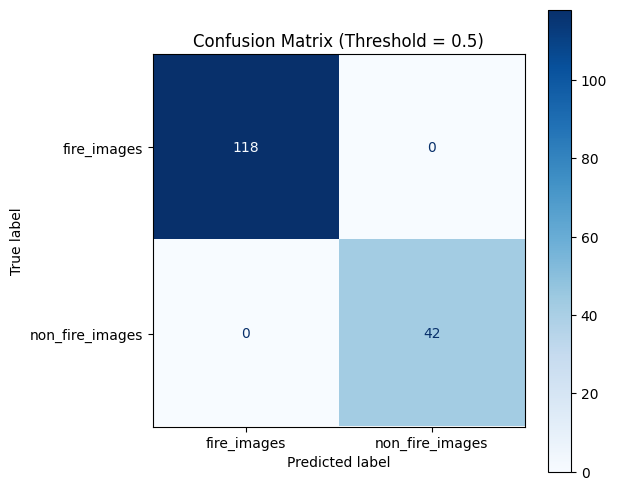

                 precision    recall  f1-score   support

    fire_images       1.00      1.00      1.00       118
non_fire_images       1.00      1.00      1.00        42

       accuracy                           1.00       160
      macro avg       1.00      1.00      1.00       160
   weighted avg       1.00      1.00      1.00       160



In [14]:
# Extract true labels and predictions from the test dataset
y_true = []
y_pred_probs = []

for images, labels in test_fire:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities to binary predictions using the default threshold of 0.5
y_pred = (y_pred_probs >= 0.5).astype(int)

# Generate and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

# Calculate recall and precision
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names_fire))

*Your answer:*


I think in this instance, a false negative would be more detrimental. If a fire is predicted but it ends up being a false alarm, people may be annoyed but no one's life would be in danger. However, if a real fire was missed and no alarm was raised, people's lives could be at stake.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [15]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [16]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
# Preprocess the data here



In [ ]:
# Build your model here



In [ ]:
# Compile your model here



## 2C — Train and Evaluate

In [ ]:
# Train your model here



In [ ]:
# Report validation and test accuracy here



## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here



*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | | |
| Test Accuracy | | |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.